# EDA: Credit Card Customer Intelligence Platform

Exploratory analysis on the BankChurners dataset, goal is to understand the data well enough to justify feature choices for 
Stage 1 (KMeans segmentation) and confirm assumptions before touching any modeling code

## Loading data 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/BankChurners.csv')
df.shape

(10127, 21)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_Revolving_B

In [9]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [11]:
# Null check 
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

Note for myself: Dataset notes say zero nulls, "Unknown" is its own category

In [12]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


## Target variable is `Attrition_Flag`

In [15]:
counts = df['Attrition_Flag'].value_counts()
pct = df['Attrition_Flag'].value_counts(normalize=True) * 100
print(counts)
print(pct.round(2))

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: proportion, dtype: float64


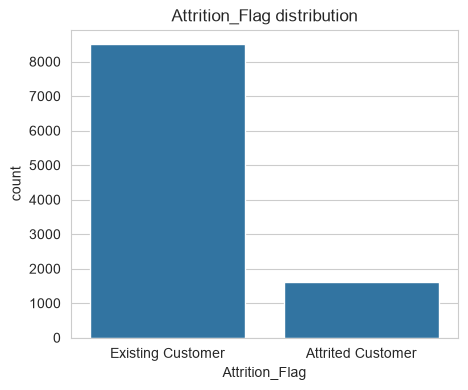

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Attrition_Flag')
plt.title('Attrition_Flag distribution')
plt.show()

## Univariate analysis on numeric features

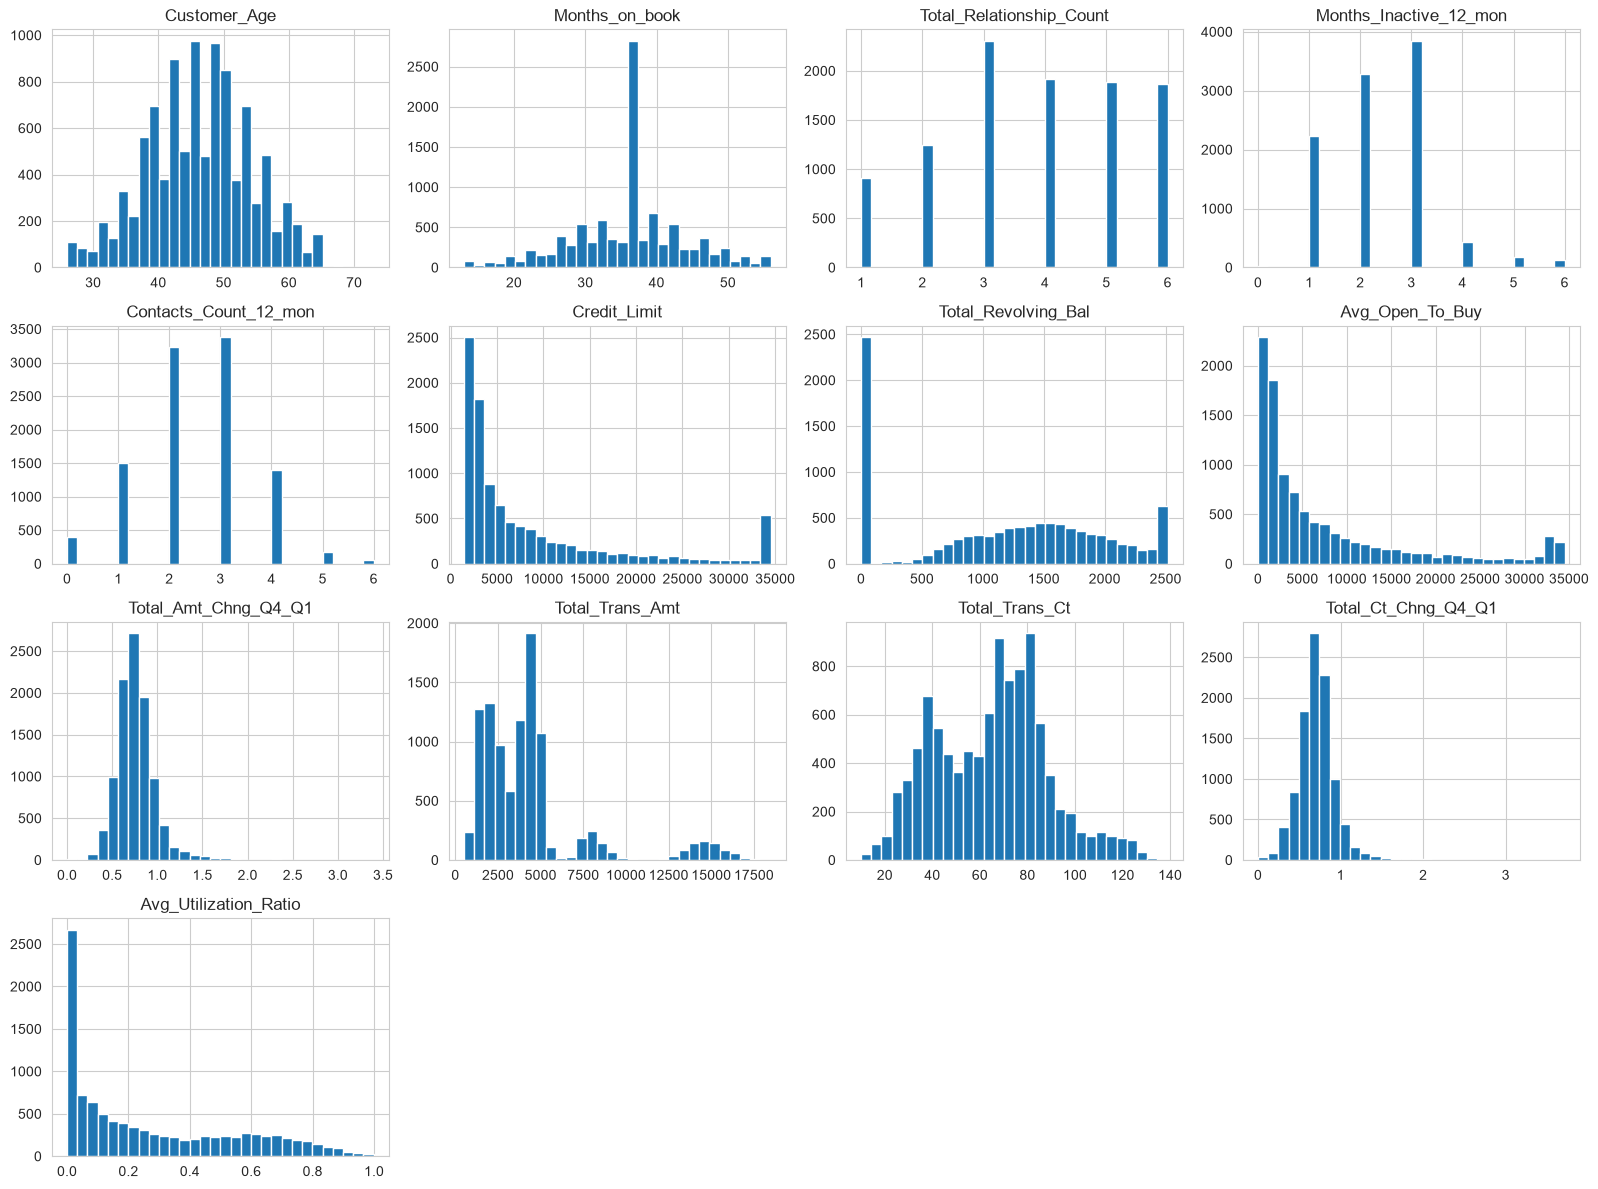

In [17]:
numeric_cols = ['Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
                'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
                'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
                'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
                'Avg_Utilization_Ratio']

df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

In [18]:
# Skewness check to check log-transform before scaling
df[numeric_cols].skew().sort_values(ascending=False)

Total_Ct_Chng_Q4_Q1         2.064031
Total_Trans_Amt             2.041003
Total_Amt_Chng_Q4_Q1        1.732063
Credit_Limit                1.666726
Avg_Open_To_Buy             1.661697
Avg_Utilization_Ratio       0.718008
Months_Inactive_12_mon      0.633061
Total_Trans_Ct              0.153673
Contacts_Count_12_mon       0.011006
Customer_Age               -0.033605
Months_on_book             -0.106565
Total_Revolving_Bal        -0.148837
Total_Relationship_Count   -0.162452
dtype: float64

## Univariate analysis on categorical features

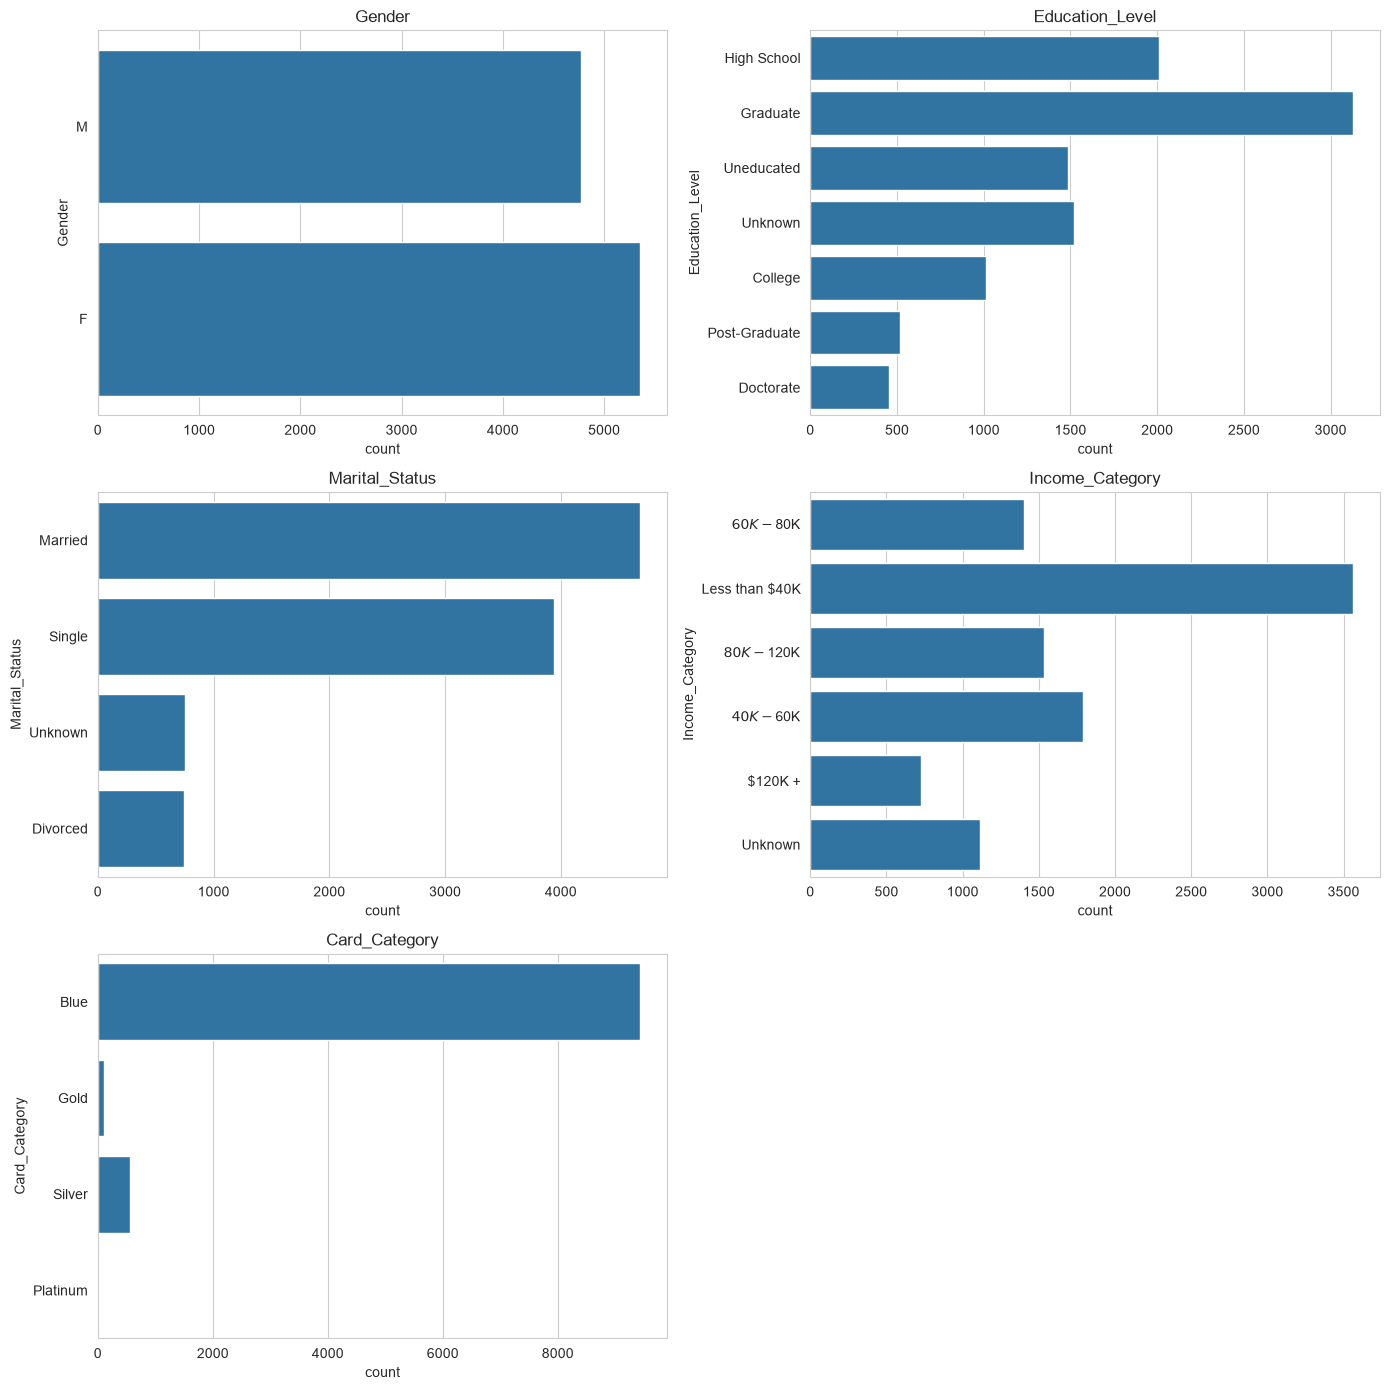

In [21]:
categorical_cols = ['Gender','Education_Level','Marital_Status','Income_Category','Card_Category']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

axes = axes.flatten()

for i in range(5):
    column_name = categorical_cols[i]
    sns.countplot(data=df,y=column_name,ax=axes[i])
    axes[i].set_title(column_name)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [24]:
# "Unknown" % in each categorical column
for i in categorical_cols:
    if 'Unknown' in df[i].values:
        percentage_unknown = (df[i] == 'Unknown').mean() * 100
        print(f"{i}: {percentage_unknown:.2f}% Unknown")

Education_Level: 15.00% Unknown
Marital_Status: 7.40% Unknown
Income_Category: 10.98% Unknown


## Bivariate Analyalysis, numeric features vs churn

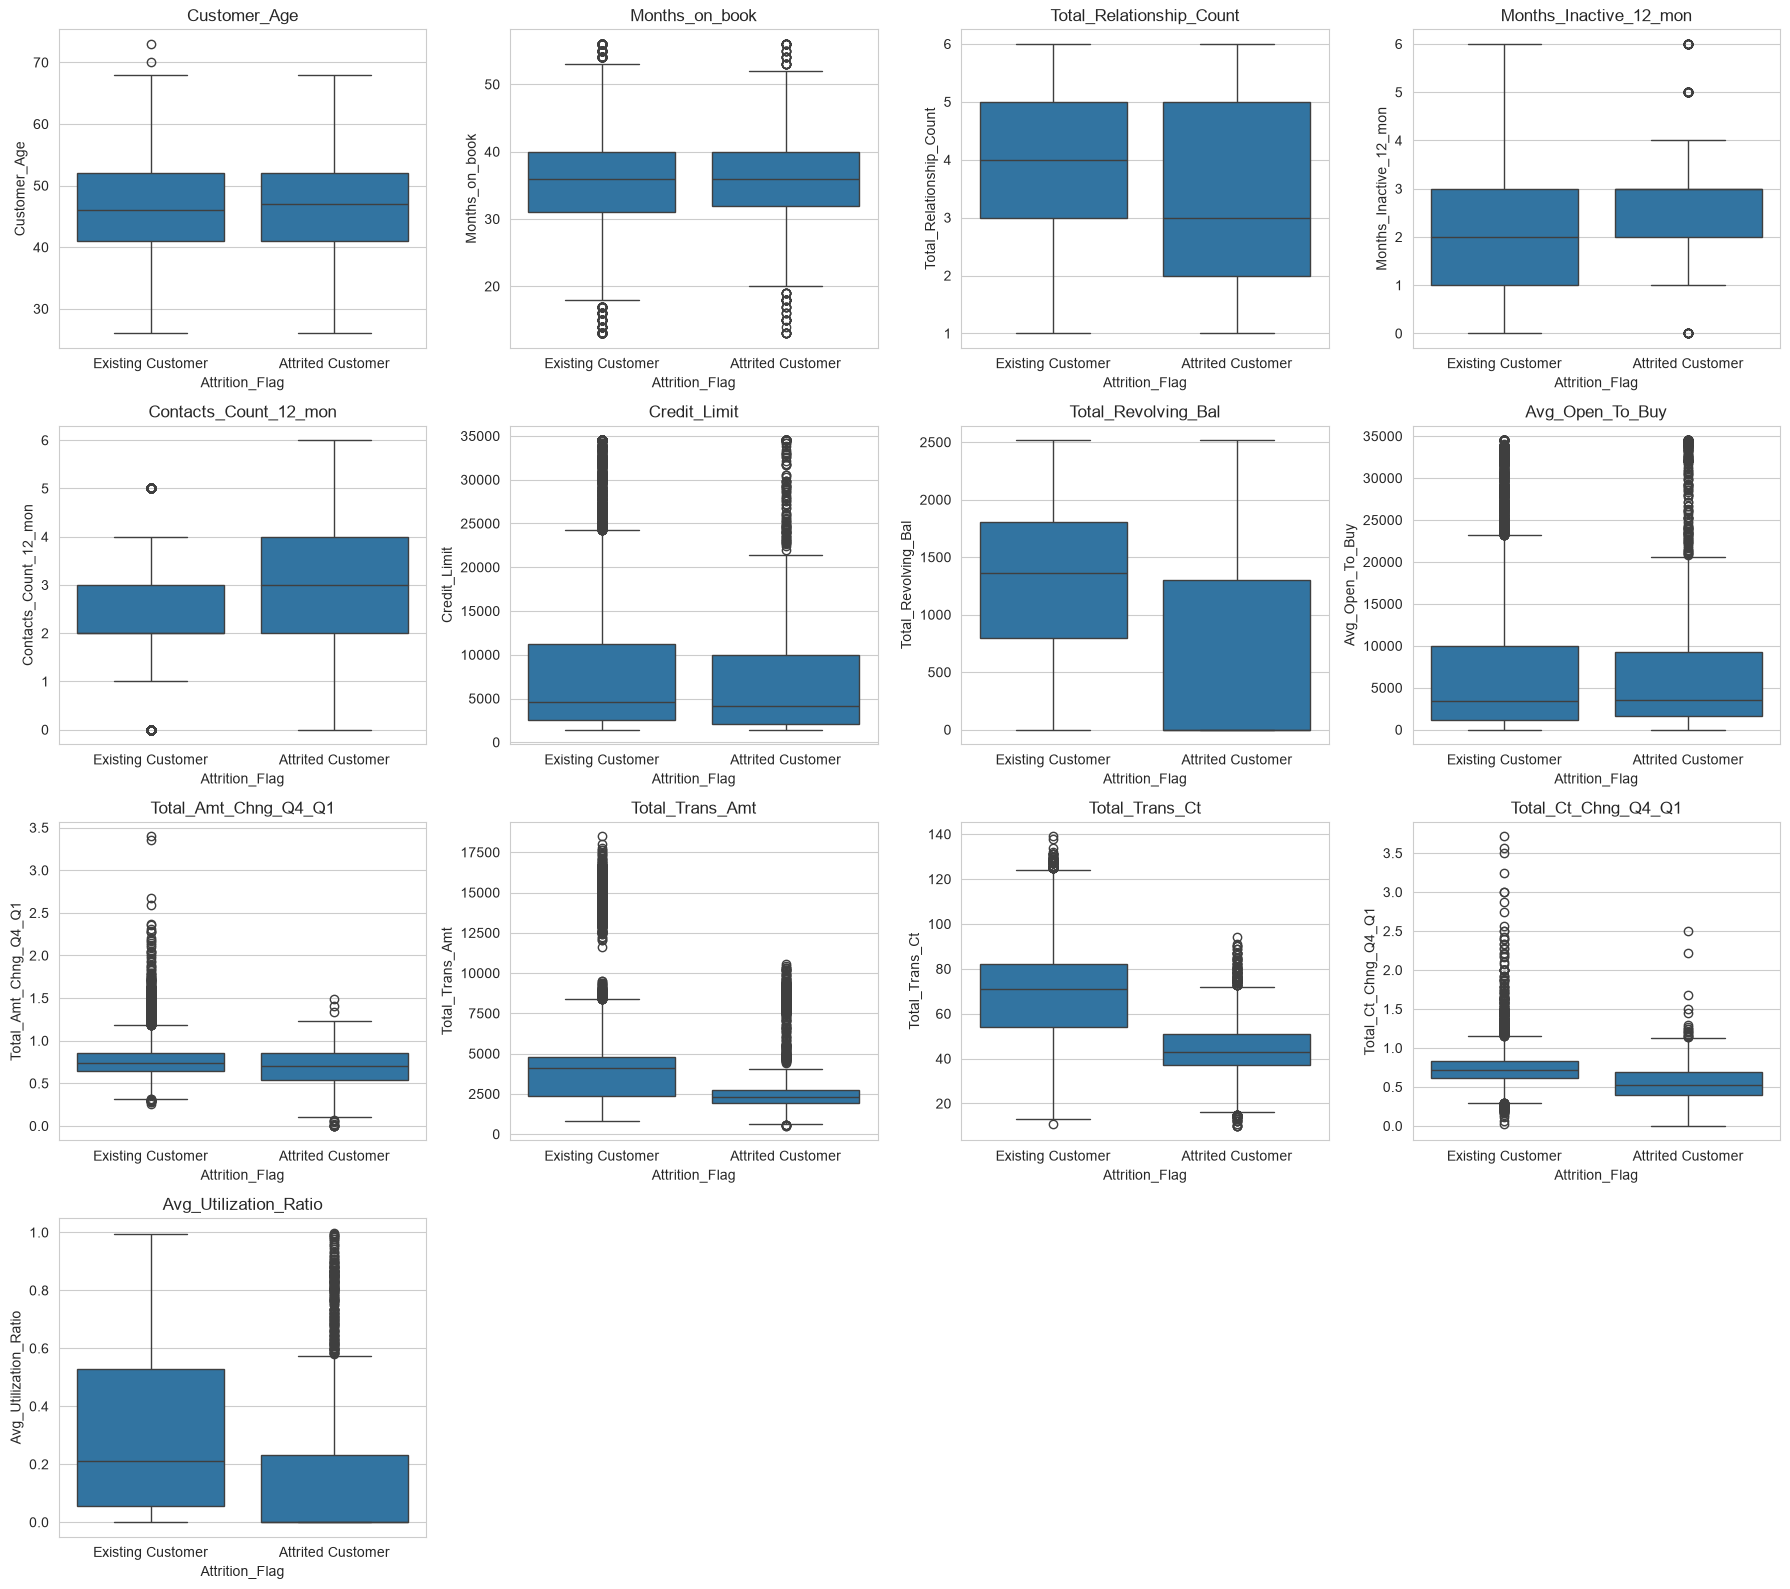

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
# Converting the plots into a simple list
axes = axes.flatten()

for i in range(len(numeric_cols)):

    column_name = numeric_cols[i]

    sns.boxplot(data=df,x='Attrition_Flag',y=column_name,ax=axes[i])
    axes[i].set_title(column_name)
    


# Deleting unused plots
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

## Bivariate Analysis, categorical features vs churn

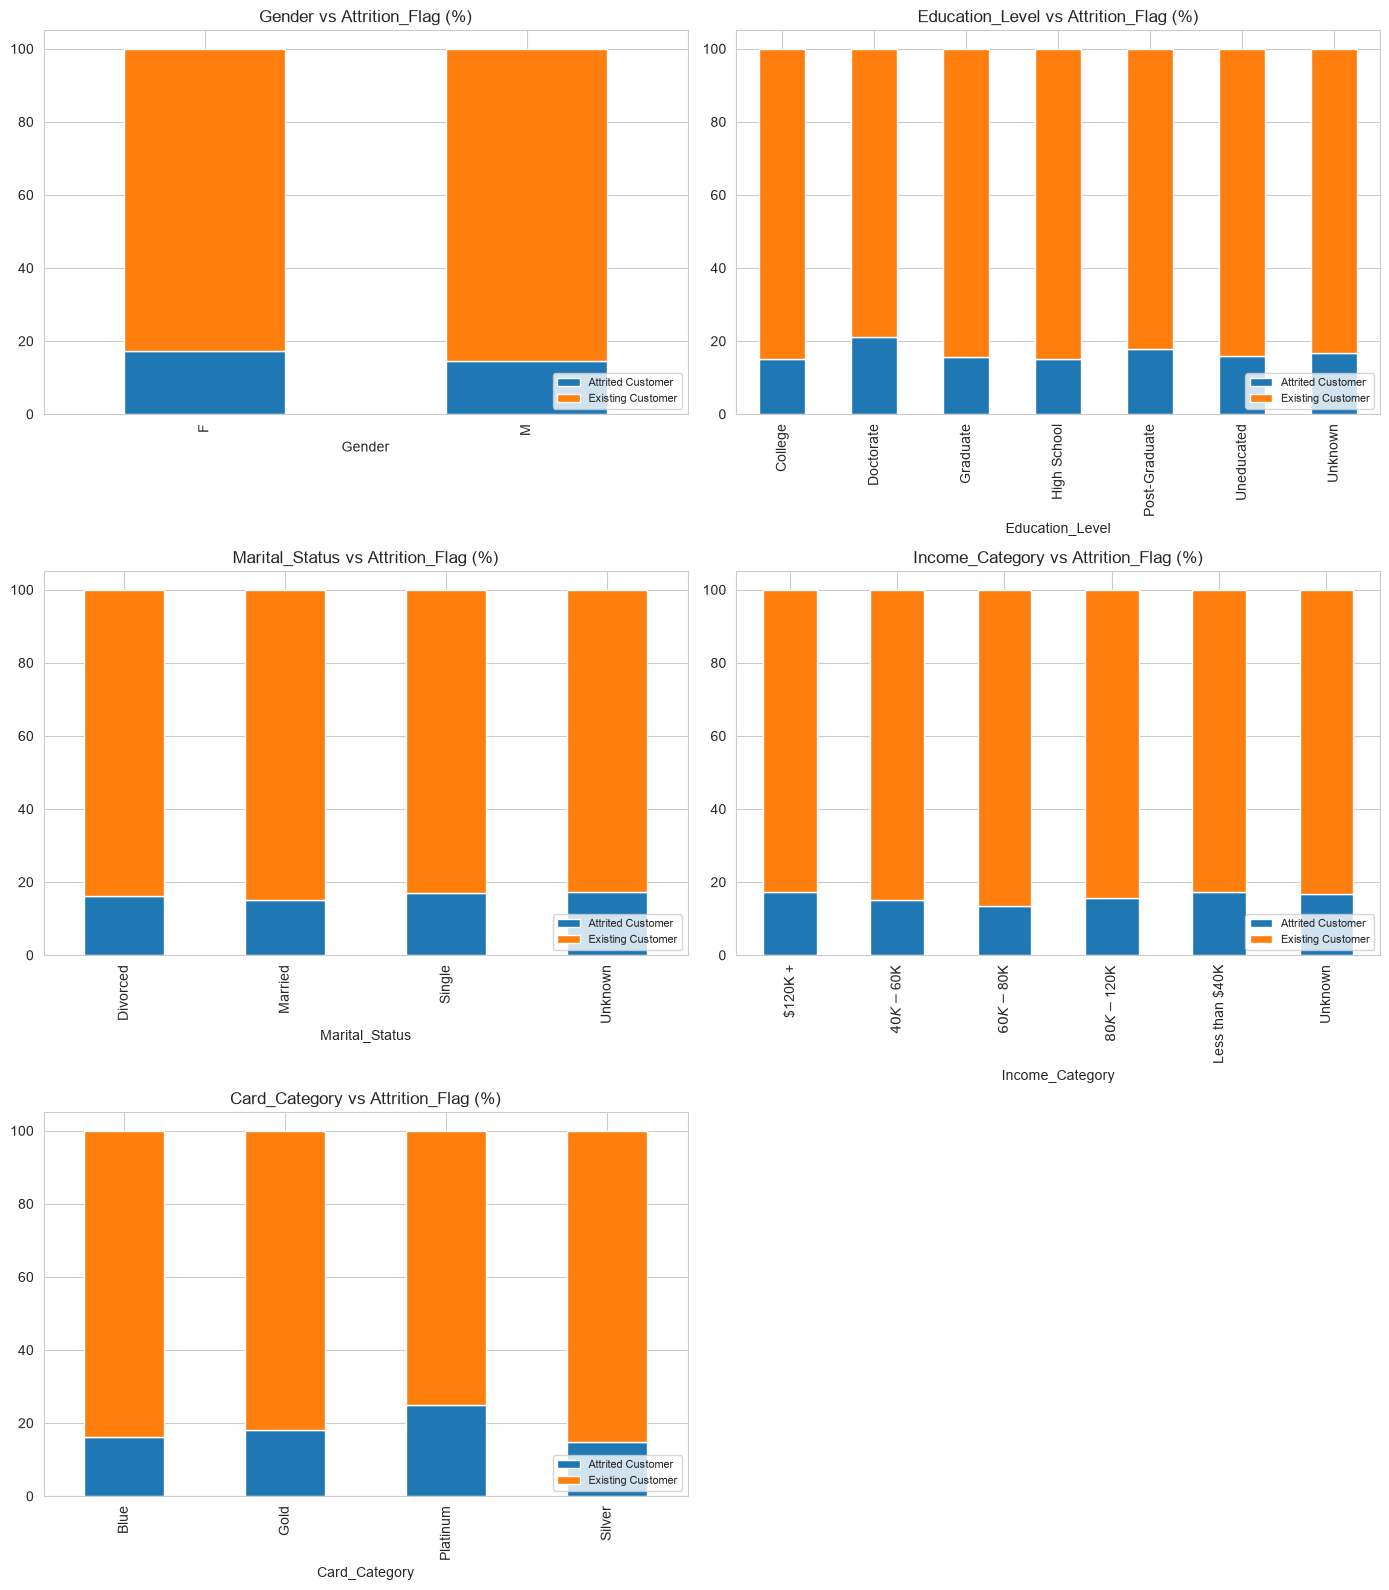

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Converting plots into a simple list
axes = axes.flatten()

for i in range(len(categorical_cols)):

    column_name = categorical_cols[i]

    # Calculate percentage of Attrition Flag
    attrition_percentage  = pd.crosstab(df[column_name],df['Attrition_Flag'],normalize='index') * 100

    # Create stacked bar chart
    attrition_percentage.plot(kind='bar',stacked=True,ax=axes[i])

    # Add title
    axes[i].set_title(column_name + ' vs Attrition_Flag (%)')

    # Show legend
    axes[i].legend(loc='lower right', fontsize=8)


# Removing the empty 6th plot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 7. Correlation heatmap — check multicollinearity

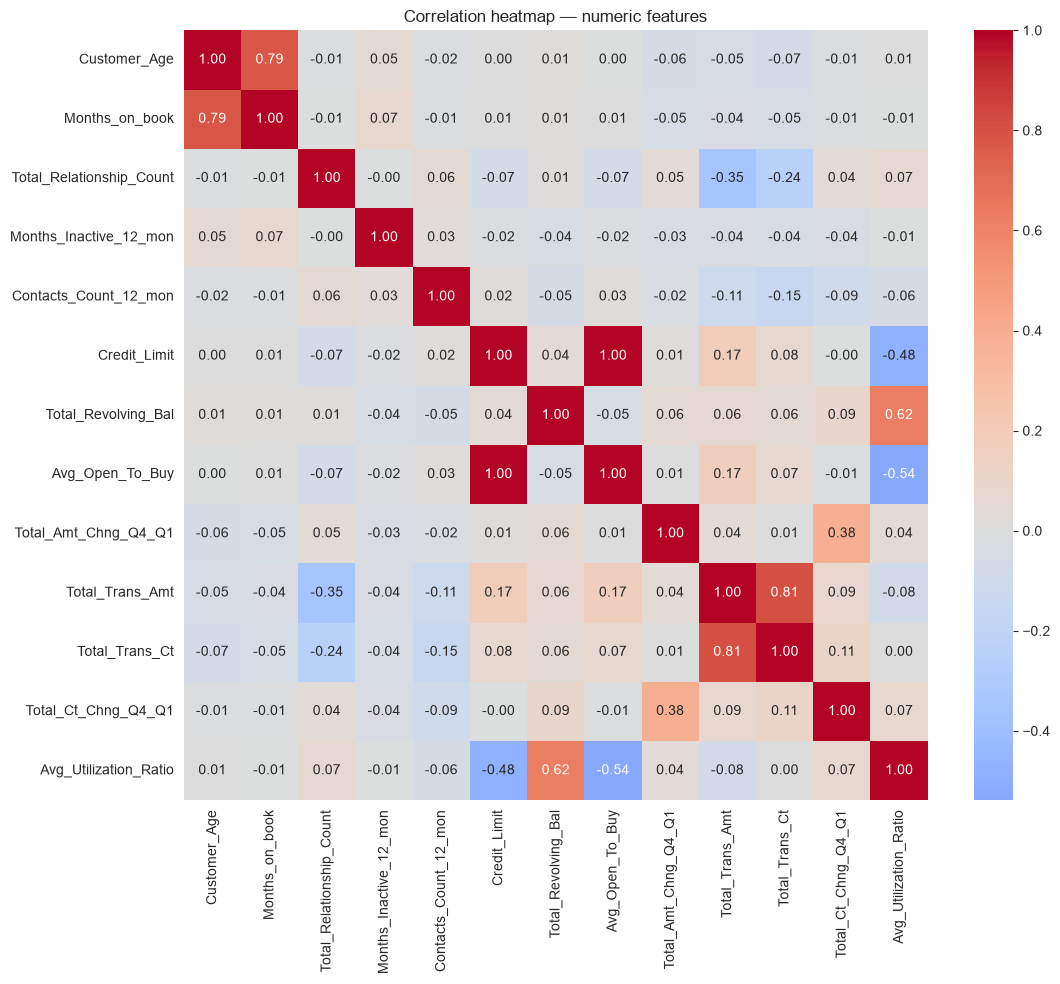

In [29]:
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap — numeric features')
plt.show()

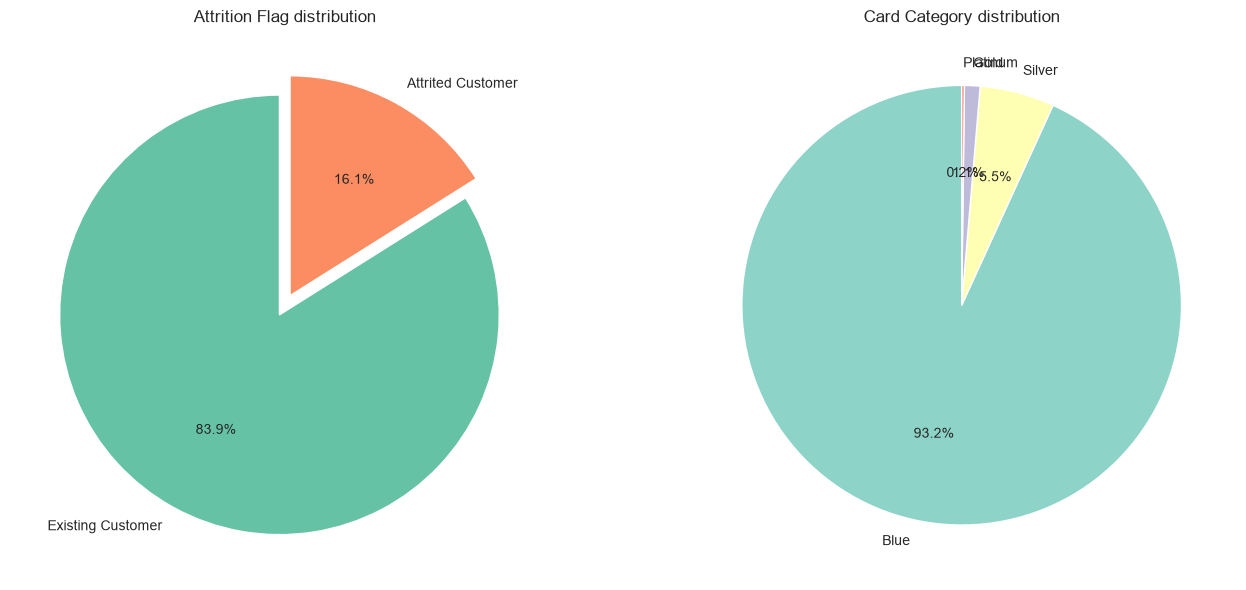

In [32]:
# Some additional pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie 1: Attrition Flag 
attrition_counts = df['Attrition_Flag'].value_counts()
axes[0].pie(attrition_counts,labels=attrition_counts.index,autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set2'),explode=[0.05, 0.05],wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[0].set_title('Attrition Flag distribution')

# Pie 2: Card Category 
card_counts = df['Card_Category'].value_counts()
axes[1].pie(card_counts,labels=card_counts.index,autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set3'),wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title('Card Category distribution')

plt.tight_layout()
plt.show()

## CONCLUSIONS:
1) `Total_Ct_Chng_Q4_Q1` (skew 2.06), `Total_Trans_Amt` (2.04), `Total_Amt_Chng_Q4_Q1` (1.73), `Credit_Limit` (1.67), and 
`Avg_Open_To_Buy` (1.66) WERE right skewed enough to need log transform before feeding into KMeans.

2) Ranked by relative mean difference between churned and retained groups:

1. `Total_Revolving_Bal` churned customers carry 60% less revolving balance
2. `Avg_Utilization_Ratio` churned customers utilize 58% less credit
3. `Total_Trans_Ct`  churned customers transact 42% less often
4. `Total_Trans_Amt`  churned customers spend 40% less
5. `Contacts_Count_12_mon`  churned customers contact support 23% more

These five are the strongest behavior signals, they should anchor the KMeans segmentation features

3) Confirmed multicollinear pairs 
- `Credit_Limit` & `Avg_Open_To_Buy` correlation 0.996 (near-perfect), Drop `Avg_Open_To_Buy` 
- `Total_Trans_Amt` & `Total_Trans_Ct`  correlation 0.81 
- `Customer_Age` ↔ `Months_on_book` correlation 0.79. 

4) `Contacts_Count_12_mon` isn't categorical in the raw data (it's numeric), but its relationship with churn is dramatically non-linear and worth flagging as a standalone strong signal